# Step 4 — Early Peeking

1. Sort the dataset by an ordering variable
2. Build cumulative conversion rates per variant
3. Plot cumulative conversion, A vs B
4. Watch the "winning variant" flip early on
5. Discuss what stopping early would have done

### Can this be the week-3 health check? Yes — with one line drawn

Step 1's peeking policy says: **anyone may look, only Oct 27 may decide.** That distinction is what
makes this notebook legitimate on Oct 13 rather than a policy violation.

| At the Oct 13 health check | |
|---|---|
| **Allowed** | Has the estimate settled or is it still moving? Is there drift or novelty decay? Does the test need longer? |
| **Allowed** | The counterfactual audit — what *would* an early stop have produced? This is a methodology question, and answering it cannot change the outcome. |
| **Not allowed** | Comparing the confidence interval to the +5% ship bar and acting on it. That is the efficacy decision, and it belongs to Oct 27 alone. |

The health check's stated job is *"is the test sound, and does it need longer?"* — which is precisely
a question about how the estimate accumulates. So this analysis does not merely fit the health check;
it **is** most of what the health check should contain.

The ship-bar comparison appears below only inside the counterfactual, labelled as the decision we
were forbidden to make. That is the point of the exercise.

## 1. Setup

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from abtest import PLAN, Z95 as Z, load, compare, two_sided_p, HEALTH_CHECK_DAY, DECISION_DAY

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
CA, CB, CWARN, COK, CMUT = "#6b7280", "#2563eb", "#dc2626", "#059669", "#c7cdd6"
SHIP = PLAN["ship_threshold_rel"]

df = load()
df["day_n"] = (df.session_date - df.session_date.min()).dt.days + 1
print(f"{len(df):,} sessions   {df.user_id.nunique():,} users   {df.day_n.max()} days")
print(f"ship threshold {SHIP:+.0%} | health check day {HEALTH_CHECK_DAY} | decision day {DECISION_DAY}")

150,568 sessions   100,000 users   35 days
ship threshold +5% | health check day 22 | decision day 35


## 2. Two orderings, two different questions

The task says *"sort by `user_id` or any timestamp-like field."* Those are not the same exercise, and
the difference is worth being deliberate about:

| Ordering | What accumulating in it shows |
|---|---|
| **`session_date`** | What we would genuinely have seen on each day of the test. This is real peeking. It mixes sampling noise with *time-varying* effects — the weekly cycle, the Oct 10 news shock, novelty decay. |
| **`user_id`** (assignment order) | An ordering unrelated to calendar time. It isolates **pure sampling noise**: no weekday effect, no novelty, no shock. Just "what does an estimate do as evidence piles up?" |

Both are built below. The calendar version is the honest simulation of peeking; the assignment-order
version is the cleaner demonstration of why peeking is dangerous *even with no time effects at all*.

### A vectorised cumulative estimator

Recomputing a clustered standard error at every checkpoint by re-filtering the DataFrame is slow and
gets slower as the window grows. Instead: build a `users × checkpoints` matrix of session counts and
conversion counts, cumulative-sum along the checkpoint axis, and evaluate the delta-method variance
at every checkpoint with array arithmetic.

This matters because the A/A simulation later needs hundreds of replicates of the whole curve.

In [2]:
def count_matrices(frame, col):
    """users x checkpoints matrices of (sessions, conversions), keyed on `col`."""
    n = frame.pivot_table(index="user_id", columns=col, values="clicked",
                          aggfunc="size", fill_value=0)
    k = frame.pivot_table(index="user_id", columns=col, values="clicked",
                          aggfunc="sum", fill_value=0).reindex_like(n).fillna(0)
    cols = list(n.columns)
    return n.to_numpy(dtype=np.int32), k.to_numpy(dtype=np.int32), cols

def cum_curve(N, K, min_users=50):
    """Per-checkpoint (sessions, conversions, rate, clustered SE), cumulative."""
    Nc, Kc = N.cumsum(1), K.cumsum(1)
    rows = []
    for d in range(N.shape[1]):
        n_i, k_i = Nc[:, d], Kc[:, d]
        act = n_i > 0
        n_i, k_i = n_i[act], k_i[act]
        M = len(n_i)
        if M < min_users:
            rows.append((0, 0, np.nan, np.nan)); continue
        ntot, ktot = int(n_i.sum()), int(k_i.sum())
        p = ktot / ntot
        nbar = ntot / M
        v = ((k_i - p * n_i) ** 2).sum() / (M - 1)
        rows.append((ntot, ktot, p, math.sqrt(v / (M * nbar ** 2))))
    return np.array(rows, dtype=float)

def curve_frame(frame, col, labels=None):
    out = {}
    for arm in ["A", "B"]:
        N, K, cols = count_matrices(frame[frame.variant == arm], col)
        out[arm] = cum_curve(N, K)
        out["_cols"] = cols
    a, b = out["A"], out["B"]
    m = min(len(a), len(b))
    a, b = a[:m], b[:m]
    se = np.sqrt(a[:, 3] ** 2 + b[:, 3] ** 2)
    d = b[:, 2] - a[:, 2]
    return pd.DataFrame({
        "checkpoint": (labels if labels is not None else out["_cols"])[:m],
        "sessions": a[:, 0] + b[:, 0],
        "ctr_a": a[:, 2], "ctr_b": b[:, 2],
        "abs_diff": d, "rel_lift": d / a[:, 2],
        "se": se, "z": d / se,
        "rel_lo": (d - Z * se) / a[:, 2], "rel_hi": (d + Z * se) / a[:, 2],
    }).dropna(subset=["z"]).reset_index(drop=True)

# ordering 1 — calendar time
by_date = curve_frame(df, "day_n")
by_date["day_n"] = by_date.checkpoint.astype(int)

# ordering 2 — assignment order, in blocks of ~1000 users
df["user_block"] = (df.user_id.str[1:].astype(int) // 1000).astype(int)
by_order = curve_frame(df, "user_block")

print(f"calendar curve      {len(by_date)} checkpoints (days)")
print(f"assignment curve    {len(by_order)} checkpoints (blocks of ~1000 users)")
by_date.head(6).style.format({"sessions":"{:,.0f}","ctr_a":"{:.4%}","ctr_b":"{:.4%}",
                              "rel_lift":"{:+.2%}","rel_lo":"{:+.2%}","rel_hi":"{:+.2%}","z":"{:.2f}"})

calendar curve      35 checkpoints (days)
assignment curve    100 checkpoints (blocks of ~1000 users)


,checkpoint,sessions,ctr_a,ctr_b,abs_diff,rel_lift,se,z,rel_lo,rel_hi,day_n
0,1,"5,151",32.9605%,37.5051%,0.045446,+13.79%,0.013367,3.40,+5.84%,+21.74%,1
1,2,"8,836",33.5795%,37.1456%,0.035661,+10.62%,0.010243,3.48,+4.64%,+16.60%,2
2,3,"13,472",33.8534%,37.5424%,0.036890,+10.90%,0.008344,4.42,+6.07%,+15.73%,3
3,4,"17,455",33.9238%,37.4332%,0.035094,+10.34%,0.007351,4.77,+6.10%,+14.59%,4
4,5,"21,575",34.1798%,37.9733%,0.037935,+11.10%,0.006659,5.70,+7.28%,+14.92%,5
5,6,"24,659",34.3561%,37.9890%,0.036329,+10.57%,0.006244,5.82,+7.01%,+14.14%,6


## 3. Cumulative conversion, A vs B

Both arms' cumulative CTR, in both orderings. The two lines converge on their true values from a
noisy start — the classic funnel shape, wide at the left because there is barely any data there.

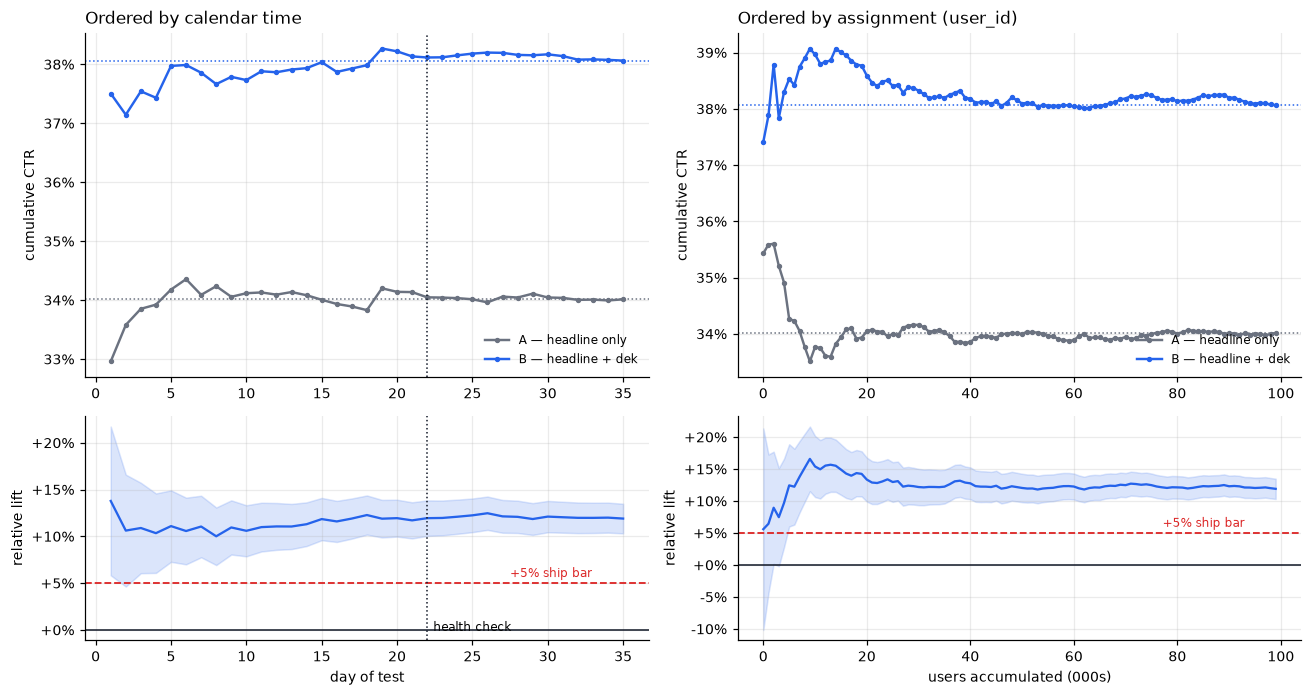

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6.4),
                       gridspec_kw={"height_ratios": [2, 1.3]})

for j, (curve, xlab, title) in enumerate([
        (by_date,  "day of test",            "Ordered by calendar time"),
        (by_order, "users accumulated (000s)", "Ordered by assignment (user_id)")]):
    x = curve.checkpoint if j == 0 else curve.checkpoint
    ax[0, j].plot(x, curve.ctr_a, color=CA, lw=1.6, marker="o", ms=2.5, label="A — headline only")
    ax[0, j].plot(x, curve.ctr_b, color=CB, lw=1.6, marker="o", ms=2.5, label="B — headline + dek")
    ax[0, j].axhline(df[df.variant=="A"].clicked.mean(), color=CA, ls=":", lw=1)
    ax[0, j].axhline(df[df.variant=="B"].clicked.mean(), color=CB, ls=":", lw=1)
    ax[0, j].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax[0, j].set_ylabel("cumulative CTR")
    ax[0, j].set_title(title, loc="left", fontsize=11)
    ax[0, j].legend(frameon=False, loc="lower right", fontsize=8)

    ax[1, j].fill_between(x, curve.rel_lo, curve.rel_hi, color=CB, alpha=0.16)
    ax[1, j].plot(x, curve.rel_lift, color=CB, lw=1.5)
    ax[1, j].axhline(0, color="#111827", lw=1)
    ax[1, j].axhline(SHIP, color=CWARN, ls="--", lw=1.2)
    ax[1, j].annotate(f"+{SHIP:.0%} ship bar", (x.iloc[-1], SHIP), xytext=(-74, 4),
                      textcoords="offset points", fontsize=8, color=CWARN)
    ax[1, j].yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
    ax[1, j].set_ylabel("relative lift"); ax[1, j].set_xlabel(xlab)

for a_ in (ax[0, 0], ax[1, 0]):
    a_.axvline(HEALTH_CHECK_DAY, color="#111827", ls=":", lw=1)
ax[1, 0].annotate("health check", (HEALTH_CHECK_DAY, ax[1,0].get_ylim()[0]), xytext=(4, 6),
                  textcoords="offset points", fontsize=8)
plt.tight_layout(); plt.show()

## 4. Does the winner flip?

Here is where our dataset fights the exercise, and it is worth saying so plainly rather than
manufacturing drama.

**The true effect is +12% relative.** That is enormous. B pulls ahead almost immediately and stays
ahead, so the *sign* of the difference barely flips at all. What does flip is the thing you would
actually act on: whether the interval clears the ship bar.

In [4]:
def flips(series):
    s = np.sign(series.to_numpy())
    s = s[s != 0]
    return int((np.diff(s) != 0).sum())

def verdict_flips(curve, bar):
    v = (curve.rel_lo > bar).to_numpy().astype(int)
    return int((np.diff(v) != 0).sum())

summary = pd.DataFrame([
    {"ordering":"calendar time",
     "checkpoints":len(by_date),
     "sign flips (who is ahead)":flips(by_date.abs_diff),
     "significance flips (CI excludes 0)":verdict_flips(by_date, 0.0),
     "ship-bar verdict flips":verdict_flips(by_date, SHIP)},
    {"ordering":"assignment order",
     "checkpoints":len(by_order),
     "sign flips (who is ahead)":flips(by_order.abs_diff),
     "significance flips (CI excludes 0)":verdict_flips(by_order, 0.0),
     "ship-bar verdict flips":verdict_flips(by_order, SHIP)},
]).set_index("ordering")
display(summary)

print("The ship-bar verdict on calendar day 1 vs day 2:")
for i in [0, 1, 2]:
    r = by_date.iloc[i]
    print(f"  day {int(r.day_n)}: lift {r.rel_lift:+7.2%}   CI lower {r.rel_lo:+7.2%}   "
          f"-> {'CLEARS +5%' if r.rel_lo > SHIP else 'does not clear'}")
print("\nNothing about the treatment changed between day 1 and day 2. One lucky draw regressed")
print("toward its true value. A day-1 stopper ships; a day-2 stopper does not.")

,checkpoints,sign flips (who is ahead),significance flips (CI excludes 0),ship-bar verdict flips
ordering,,,,
calendar time,35,0,0,2
assignment order,100,0,3,1


The ship-bar verdict on calendar day 1 vs day 2:
  day 1: lift +13.79%   CI lower  +5.84%   -> CLEARS +5%
  day 2: lift +10.62%   CI lower  +4.64%   -> does not clear
  day 3: lift +10.90%   CI lower  +6.07%   -> CLEARS +5%

Nothing about the treatment changed between day 1 and day 2. One lucky draw regressed
toward its true value. A day-1 stopper ships; a day-2 stopper does not.


### Zooming into the first 3,000 sessions

At the very start, where a real peeker is at their most excitable.

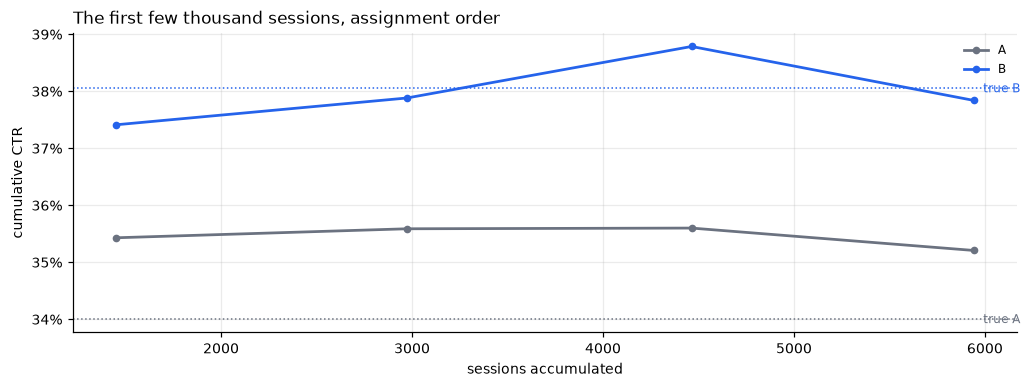

At 1,450 sessions the observed lift is +5.59% with CI [-10.16%, +21.35%] — an interval wide enough to contain almost any story.


In [5]:
first = by_order[by_order.sessions <= 6000]
fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(first.sessions, first.ctr_a, color=CA, lw=1.8, marker="o", ms=4, label="A")
ax.plot(first.sessions, first.ctr_b, color=CB, lw=1.8, marker="o", ms=4, label="B")
ax.axhline(df[df.variant=="A"].clicked.mean(), color=CA, ls=":", lw=1)
ax.axhline(df[df.variant=="B"].clicked.mean(), color=CB, ls=":", lw=1)
ax.annotate("true A", (first.sessions.iloc[-1], df[df.variant=="A"].clicked.mean()),
            xytext=(6, -3), textcoords="offset points", fontsize=8, color=CA)
ax.annotate("true B", (first.sessions.iloc[-1], df[df.variant=="B"].clicked.mean()),
            xytext=(6, -3), textcoords="offset points", fontsize=8, color=CB)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("sessions accumulated"); ax.set_ylabel("cumulative CTR")
ax.set_title("The first few thousand sessions, assignment order", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f"At {int(first.sessions.iloc[0]):,} sessions the observed lift is "
      f"{first.rel_lift.iloc[0]:+.2%} with CI [{first.rel_lo.iloc[0]:+.2%}, "
      f"{first.rel_hi.iloc[0]:+.2%}] — an interval wide enough to contain almost any story.")

## 5. The A/A test — where flipping is real, and where peeking actually bites

The problem with demonstrating peeking on a +12% effect is that peeking mostly *works* here. You
would have got the right answer early. That is survivorship: you only know the effect was huge
**after** the test finished.

So run the case that matters. Split **arm A against itself** — randomly, at user level. The true
effect is exactly zero by construction. Then peek daily and see what a naive
*stop-when-p&lt;0.05* rule does.

In [6]:
arm_a = df[df.variant == "A"]
N_A, K_A, day_cols = count_matrices(arm_a, "day_n")
print(f"arm A: {N_A.shape[0]:,} users x {N_A.shape[1]} days, "
      f"{int(N_A.sum()):,} sessions, {int(K_A.sum()):,} conversions")

def aa_replicate(rng):
    """One A/A split of arm A. Returns the per-day z curve and rate difference."""
    mask = rng.random(N_A.shape[0]) < 0.5
    c1 = cum_curve(N_A[mask], K_A[mask])
    c2 = cum_curve(N_A[~mask], K_A[~mask])
    se = np.sqrt(c1[:, 3] ** 2 + c2[:, 3] ** 2)
    d = c2[:, 2] - c1[:, 2]
    with np.errstate(invalid="ignore", divide="ignore"):
        return d / se, d / c1[:, 2], c1[:, 0] + c2[:, 0]

rng = np.random.default_rng(4)
R = 400
ever, final, first_day, lift_at_stop, n_flips = [], [], [], [], []
for _ in range(R):
    z, rel, n = aa_replicate(rng)
    ok = ~np.isnan(z)
    sig = np.abs(z) > Z
    ever.append(bool((sig & ok).any()))
    final.append(bool(sig[ok][-1]))
    n_flips.append(int((np.diff(np.sign(z[ok])) != 0).sum()))
    if (sig & ok).any():
        i = int(np.argmax(sig & ok))
        first_day.append(i + 1)
        lift_at_stop.append(rel[i])

aa = pd.DataFrame([
    {"rule":"Look ONCE, at the end (the pre-registered design)",
     "false positive rate":np.mean(final)},
    {"rule":"Peek DAILY, stop the first time p < 0.05",
     "false positive rate":np.mean(ever)},
]).set_index("rule")
display(aa.style.format({"false positive rate":"{:.1%}"}))

print(f"{R} A/A replicates, true effect exactly zero, alpha = 0.05.\n")
print(f"  looking once   -> {np.mean(final):.1%} false positives   (should be ~5%)")
print(f"  peeking daily  -> {np.mean(ever):.1%} false positives   "
      f"({np.mean(ever)/max(np.mean(final),1e-9):.1f}x inflation)")
print(f"\n  median sign flips per replicate: {int(np.median(n_flips))} "
      f"(who is 'winning' changes this many times in a test with NO effect)")
if lift_at_stop:
    print(f"\n  Among replicates that hit significance, the observed relative lift at the moment")
    print(f"  of stopping averaged {np.mean(np.abs(lift_at_stop)):+.2%} — reported as a real effect,")
    print(f"  when the truth is 0.00%. Median stop was day {int(np.median(first_day))}.")

arm A: 52,116 users x 35 days, 78,341 sessions, 26,647 conversions


,false positive rate
rule,
"Look ONCE, at the end (the pre-registered design)",5.2%
"Peek DAILY, stop the first time p < 0.05",24.8%


400 A/A replicates, true effect exactly zero, alpha = 0.05.

  looking once   -> 5.2% false positives   (should be ~5%)
  peeking daily  -> 24.8% false positives   (4.7x inflation)

  median sign flips per replicate: 3 (who is 'winning' changes this many times in a test with NO effect)

  Among replicates that hit significance, the observed relative lift at the moment
  of stopping averaged +6.86% — reported as a real effect,
  when the truth is 0.00%. Median stop was day 5.


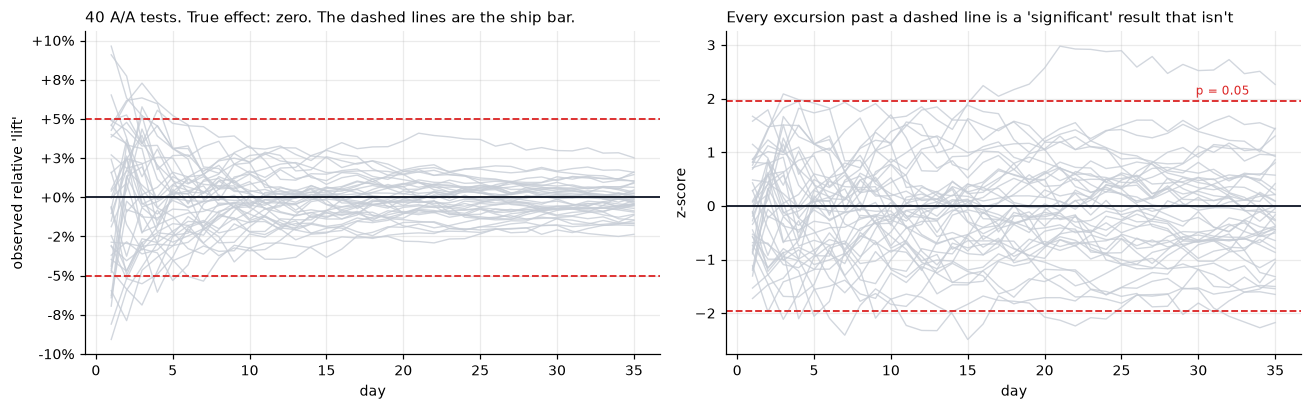

In [7]:
rng2 = np.random.default_rng(11)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

for _ in range(40):
    z, rel, n = aa_replicate(rng2)
    ok = ~np.isnan(rel)
    ax[0].plot(np.arange(1, len(rel) + 1)[ok], rel[ok], color=CMUT, lw=0.9, alpha=0.8)
    ax[1].plot(np.arange(1, len(z) + 1)[ok], z[ok], color=CMUT, lw=0.9, alpha=0.8)

ax[0].axhline(0, color="#111827", lw=1.2)
ax[0].axhline(SHIP, color=CWARN, ls="--", lw=1.2)
ax[0].axhline(-SHIP, color=CWARN, ls="--", lw=1.2)
ax[0].yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax[0].set_xlabel("day"); ax[0].set_ylabel("observed relative 'lift'")
ax[0].set_title("40 A/A tests. True effect: zero. The dashed lines are the ship bar.",
                loc="left", fontsize=10)

ax[1].axhline(0, color="#111827", lw=1.2)
for s in (Z, -Z):
    ax[1].axhline(s, color=CWARN, ls="--", lw=1.2)
ax[1].annotate("p = 0.05", (len(z), Z), xytext=(-52, 4), textcoords="offset points",
               fontsize=8, color=CWARN)
ax[1].set_xlabel("day"); ax[1].set_ylabel("z-score")
ax[1].set_title("Every excursion past a dashed line is a 'significant' result that isn't",
                loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 6. What stopping early would have done

Two columns, and the gap between them is the whole lesson: what you would have **concluded**, and
what was actually **true** at that moment.

In [8]:
truth = compare(df)
scenarios = []
for d in [1, 2, 3, 5, 7, 14, HEALTH_CHECK_DAY, 28, DECISION_DAY]:
    r = by_date[by_date.day_n == d]
    if not len(r):
        continue
    r = r.iloc[0]
    sig  = r.rel_lo > 0
    ship = r.rel_lo > SHIP
    call = ("SHIP" if ship else ("real but below bar" if sig else "no effect detected"))
    scenarios.append({
        "stopped on day": d,
        "sessions": int(r.sessions),
        "observed lift": r.rel_lift,
        "95% CI": f"[{r.rel_lo:+.2%}, {r.rel_hi:+.2%}]",
        "call you'd have made": call,
        "error vs final (rel pts)": (r.rel_lift - truth["rel_lift"]) * 100,
    })
sc = pd.DataFrame(scenarios).set_index("stopped on day")
display(sc.style.format({"sessions":"{:,}","observed lift":"{:+.2%}","error vs final (rel pts)":"{:+.2f}"}))

print(f"final answer at day {DECISION_DAY}: {truth['rel_lift']:+.2%} "
      f"[{truth['rel_lo']:+.2%}, {truth['rel_hi']:+.2%}]\n")
d1 = sc.iloc[0]
print(f"A day-1 stop would have reported {d1['observed lift']:+.2%} against a final "
      f"{truth['rel_lift']:+.2%} — overstating the relative lift by "
      f"{d1['error vs final (rel pts)']:+.2f} points.")
print("Every one of those early calls happens to point the right way here. That is a property of a")
print("+12% effect, not a property of peeking. The A/A results above are what peeking looks like")
print("when the effect is not there to rescue you.")

,sessions,observed lift,95% CI,call you'd have made,error vs final (rel pts)
stopped on day,,,,,
1,"5,151",+13.79%,"[+5.84%, +21.74%]",SHIP,+1.88
2,"8,836",+10.62%,"[+4.64%, +16.60%]",real but below bar,-1.28
3,"13,472",+10.90%,"[+6.07%, +15.73%]",SHIP,-1.01
5,"21,575",+11.10%,"[+7.28%, +14.92%]",SHIP,-0.81
7,"29,568",+11.05%,"[+7.77%, +14.34%]",SHIP,-0.85
14,"61,306",+11.30%,"[+8.97%, +13.64%]",SHIP,-0.60
22,"97,743",+11.95%,"[+10.05%, +13.84%]",SHIP,+0.04
28,"121,910",+12.09%,"[+10.36%, +13.82%]",SHIP,+0.18
35,"150,568",+11.90%,"[+10.32%, +13.49%]",SHIP,+0.00


final answer at day 35: +11.90% [+10.32%, +13.49%]

A day-1 stop would have reported +13.79% against a final +11.90% — overstating the relative lift by +1.88 points.
Every one of those early calls happens to point the right way here. That is a property of a
+12% effect, not a property of peeking. The A/A results above are what peeking looks like
when the effect is not there to rescue you.


## 7. Discussion — what would happen if you stopped early

### The mechanism

Each look is a fresh chance to cross the threshold. Under a true null, one look carries a 5% false
positive rate; the daily-peeking simulation above measures what 35 looks costs, using this
project's own data rather than a textbook figure. Nothing about the treatment changes between looks —
only the number of opportunities to be unlucky.

### The three costs, in order of how often they bite

**1. False positives.** Measured above. You ship a change that does nothing, absorb the
implementation cost, and — worse — record a "win" that becomes a premise for the next decision.

**2. The winner's curse.** Stopping the moment you cross the line selects for the *most flattering*
moment in a noisy series. So the effect you report is systematically inflated: you stop on a high
draw, then reality regresses. The A/A number above quantifies it for a true effect of exactly zero,
and the day-1 row in section 6 shows it on the real data. Practical consequence: even when the
direction is right, the *magnitude* you promised is not what you get, and the forecast built on it
is wrong.

**3. False negatives, from the other direction.** Stopping early on a *disappointing* interim is the
same error with the sign flipped. A test killed at day 4 with a wide interval has not shown the
effect is absent — it has shown nothing. That is exactly the status of Feb 2026's headline-length
test in the company brief, and why nobody can cite it for anything.

### The asymmetry that makes guardrails legitimate

Step 1 monitors guardrails **daily** while permitting only one efficacy look, and that is not
inconsistent. Guardrails can only ever **stop** the test; they can never declare a win. Peeking to
protect users is one-directional and its false alarms cost an investigation. Peeking for success is
what manufactures the false positive.

### Why this design is safe from all of it

Sample size was never the constraint — the test is powered for +2% relative within about a day. There
was therefore nothing to gain from an early stop and everything to lose, which is why Step 1 settled
on **one efficacy analysis at the full α = 0.05, on Oct 27, with no decision available at any earlier
date.** The alternative — an alpha-spending rule such as O'Brien-Fleming — solves a *resource*
problem: it buys you a legitimate early exit when data is scarce and expensive. Here data is neither.

Note the practical benefit: because no decision is available on Oct 13, there is nothing to argue
about on Oct 13. A design with a legal early-stop threshold turns every interim into a negotiation.

### So: what belongs in the Oct 13 health check

**Include** — everything in sections 2, 3, 4 and 5: has the estimate settled, how wide is the interval
still, is there drift, and the A/A demonstration as the standing reminder of why the policy exists.
Plus the validity gates: SRM, coverage, instrumentation, rendering.

**Exclude** — section 6. The scenario table is a *retrospective*, safe to run once the decision date
has passed. Presenting it on Oct 13 would put the ship-bar comparison in front of the room while the
decision is still live, which is the peek the policy exists to prevent. Some analyses are safe only
after they can no longer change anything.

---
## Caveat

The real-data half of this notebook is a weak demonstration **because the effect is too large** —
+12% relative, where Step 1 powered for +2% and would ship at +5%. Peeking would have got the right
answer on day 1.

Which is exactly the trap the A/A section exists to expose: you cannot tell in advance whether you
are in the +12% world where peeking looks harmless, or the 0% world where it manufactures a
confident, sizeable, entirely fictional result. The policy has to be set before you know which one
you are in.

Set `TARGET_B = 0.351` in `02-synthetic-data.ipynb` for the +3% version, and the real-data curves
start behaving like the A/A curves: flipping for weeks, crossing and re-crossing the ship bar, and
rewarding whoever happens to look on a good day.